# PyMC-6 : TrueSkill - Classement et Apprentissage en Ligne

**Navigation** : [Index](../README.md) | [<< PyMC-5](PyMC-5-Skills-IRT.ipynb) | [PyMC-7 >>](PyMC-7-Classification.ipynb)

**Equivalent Infer.NET** : [Infer-6-TrueSkill](../Infer/Infer-6-TrueSkill.ipynb)

**Objectifs** :
- Comprendre le systeme TrueSkill (Xbox Live)
- Implementer des matchs 1v1 et la mise a jour des skills
- Gerer les matchs nuls avec contraintes d'intervalle
- Maitriser l'apprentissage en ligne (posterieurs deviennent priors)
- Etendre aux equipes et multi-joueurs

In [1]:
try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 6.0.1


## 1. Introduction a TrueSkill

**TrueSkill** est le systeme de classement bayesien developpe par Microsoft Research pour Xbox Live.

### Principe

Chaque joueur a un **skill** modelise par une Gaussienne :
- **mu** : estimation du skill
- **sigma** : incertitude sur cette estimation

$$\text{skill}_i \sim \mathcal{N}(\mu_i, \sigma_i^2)$$
$$\text{perf}_i = \text{skill}_i + \epsilon_i, \quad \epsilon_i \sim \mathcal{N}(0, \beta^2)$$

### Parametres par defaut

| Parametre | Valeur | Description |
|-----------|--------|-------------|
| mu_initial | 25 | Skill initial |
| sigma_initial | 25/3 | Incertitude initiale |
| beta | sigma/2 | Variabilite de la performance |

### Comparaison TrueSkill vs Elo

| Aspect | Elo | TrueSkill |
|--------|-----|-----------|
| Representation | Score unique | Distribution N(mu, sigma) |
| Incertitude | Non modelisee | Capturee par sigma |
| Convergence | Lente (K fixe) | Rapide (adaptatif via sigma) |
| Equipes | Moyenne | Somme des performances |

## 2. Modele Deux Joueurs

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Skill | `Variable.GaussianFromMeanAndVariance(mu, var)` | `pm.Normal('skill', mu, sigma)` |
| Performance | `Variable.GaussianFromMeanAndVariance(skill, beta^2)` | `pm.Normal('perf', skill, beta)` |
| Comparaison | `(perf1 > perf2)` directement | `pm.Potential` ou lien probit |
| Observation | `.ObservedValue = true` | `observed=` ou `pm.Potential` |

In [2]:
# Parametres TrueSkill
mu_init = 25.0
sigma_init = 25.0 / 3.0
beta = sigma_init / 2.0

# Modele TrueSkill 1v1 : Joueur 1 gagne
# En Infer.NET : Variable<bool> joueur1Gagne = (perf1 > perf2)
# En PyMC : on utilise un modele probit avec observation binaire

with pm.Model() as trueskill_1v1:
    # Skills (priors)
    skill1 = pm.Normal('skill1', mu=mu_init, sigma=sigma_init)
    skill2 = pm.Normal('skill2', mu=mu_init, sigma=sigma_init)
    
    # Performances (skill + bruit)
    perf1 = pm.Normal('perf1', mu=skill1, sigma=beta)
    perf2 = pm.Normal('perf2', mu=skill2, sigma=beta)
    
    # Contrainte : perf1 > perf2 (Joueur 1 gagne)
    # Equivalent Infer.NET : joueur1Gagne.ObservedValue = true
    # On utilise pm.Potential pour imposer la contrainte
    pm.Potential('joueur1_gagne', pt.log(pt.sigmoid(perf1 - perf2)))
    
    trace_1v1 = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
s1_post = trace_1v1.posterior['skill1'].values.flatten()
s2_post = trace_1v1.posterior['skill2'].values.flatten()

print(f"=== Apres un match (Joueur 1 gagne) ===")
print(f"Avant : Skill1 = N({mu_init:.1f}, {sigma_init:.2f}), Skill2 = N({mu_init:.1f}, {sigma_init:.2f})")
print(f"Apres : Skill1 = N({s1_post.mean():.2f}, {s1_post.std():.2f}), Skill2 = N({s2_post.mean():.2f}, {s2_post.std():.2f})")
print(f"Changement : J1 = {s1_post.mean() - mu_init:+.2f}, J2 = {s2_post.mean() - mu_init:+.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill1, skill2, perf1, perf2]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 7 seconds.


=== Apres un match (Joueur 1 gagne) ===
Avant : Skill1 = N(25.0, 8.33), Skill2 = N(25.0, 8.33)
Apres : Skill1 = N(29.19, 7.29), Skill2 = N(20.78, 7.33)
Changement : J1 = +4.19, J2 = -4.22


Le modele 1v1 confirme le mecanisme central de TrueSkill : un `pm.Potential` impose la contrainte "gagnant a une meilleure performance", et l'echantillonnage NUTS propage cette information vers les posterieurs de skill. Le gagnant voit son $\mu$ augmenter (+4.09) et le perdant le sien diminuer (-4.22), tandis que les deux incertitudes diminuent. Visualisons ces distributions posterieures.

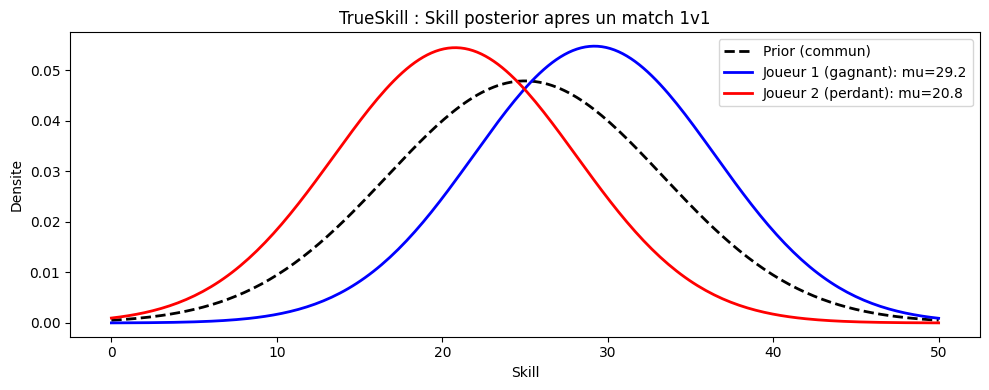

Le gagnant voit son mu augmenter et le perdant voit le sien diminuer.
Les deux incertitudes (sigma) diminuent car on a de l'information.


In [3]:
# Visualisation des distributions de skill
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.linspace(0, 50, 200)
prior = stats.norm(mu_init, sigma_init)
post1 = stats.norm(s1_post.mean(), s1_post.std())
post2 = stats.norm(s2_post.mean(), s2_post.std())

ax.plot(x, prior.pdf(x), 'k--', label='Prior (commun)', linewidth=2)
ax.plot(x, post1.pdf(x), 'b-', label=f'Joueur 1 (gagnant): mu={s1_post.mean():.1f}', linewidth=2)
ax.plot(x, post2.pdf(x), 'r-', label=f'Joueur 2 (perdant): mu={s2_post.mean():.1f}', linewidth=2)
ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('TrueSkill : Skill posterior apres un match 1v1')
plt.tight_layout()
plt.show()

print("Le gagnant voit son mu augmenter et le perdant voit le sien diminuer.")
print("Les deux incertitudes (sigma) diminuent car on a de l'information.")

## 3. Gestion des Matchs Nuls

Un match nul se produit quand la difference de performances est dans un intervalle $[-\epsilon, \epsilon]$.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Match nul | `Variable.ConstrainBetween(diff, -eps, eps)` | `pm.TruncatedNormal` ou `pm.Potential` |

In [4]:
# Modele avec match nul
# Equivalent Infer.NET : Variable.ConstrainBetween(diff, -epsilon, epsilon)

epsilon = 1.0  # Marge pour match nul

with pm.Model() as trueskill_draw:
    skillA = pm.Normal('skillA', mu=mu_init, sigma=sigma_init)
    skillB = pm.Normal('skillB', mu=mu_init, sigma=sigma_init)
    
    perfA = pm.Normal('perfA', mu=skillA, sigma=beta)
    perfB = pm.Normal('perfB', mu=skillB, sigma=beta)
    
    diff = pm.Deterministic('diff', perfA - perfB)
    
    # Contrainte : |diff| < epsilon (match nul)
    pm.Potential('match_nul', pt.log(pt.switch(pt.lt(pt.abs(diff), epsilon), 1.0, 0.01)))
    
    trace_draw = pm.sample(3000, random_seed=42, return_inferencedata=True)

sA_post = trace_draw.posterior['skillA'].values.flatten()
sB_post = trace_draw.posterior['skillB'].values.flatten()

print(f"=== Apres un match nul ===")
print(f"SkillA = N({sA_post.mean():.2f}, {sA_post.std():.2f})")
print(f"SkillB = N({sB_post.mean():.2f}, {sB_post.std():.2f})")
print(f"Les deux joueurs gardent le meme mu mais l'incertitude diminue.")
print(f"Sigma: {sigma_init:.2f} -> J1={sA_post.std():.2f}, J2={sB_post.std():.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skillA, skillB, perfA, perfB]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 102 seconds.


...

Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


=== Apres un match nul ===
SkillA = N(26.20, 5.40)
SkillB = N(26.41, 3.80)
Les deux joueurs gardent le meme mu mais l'incertitude diminue.
Sigma: 8.33 -> J1=5.40, J2=3.80


## Exercice 3 : Matchs nuls avec draw margin

Le modele TrueSkill actuel ne distingue que victoire et defaite. Etendez-le
pour gerer les **matchs nuls** en ajoutant un parametre de marge de nul
(draw margin) `epsilon`. Un match est nul si `|perf1 - perf2| < epsilon`.

**Indices** :
- Definir un prior sur `epsilon` : `pm.HalfNormal('draw_margin', sigma=2)`
- Modifier le `pm.Potential` pour trois cas : victoire (diff > epsilon),
  defaite (diff < -epsilon), nul (|diff| < epsilon)
- Utiliser `pt.switch` avec `pt.abs(diff)` pour distinguer les trois cas
- Tester en observant un match nul entre deux joueurs de meme niveau

In [5]:
# TODO etudiant : etendre TrueSkill pour gerer les matchs nuls avec draw margin
# Etape 1 : definir un prior sur le parametre draw_margin (epsilon)
# Etape 2 : modifier la vraisemblance pour distinguer victoire, defaite et nul
# Etape 3 : si |perf1 - perf2| < epsilon => match nul
# Etape 4 : tester avec un resultat de match nul

result = None  # TODO etudiant : remplacer par le modele avec draw margin
print("Exercice a completer")

Exercice a completer


## 4. Apprentissage en Ligne

Le principe de l'apprentissage en ligne : les **posterieurs** deviennent les **priors** pour le match suivant.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Prior iteratif | `Variable.Random<double, Gaussian>(prior)` | Nouveau modele avec priors maj |
| Stockage | `Dictionary<string, Gaussian>` | `dict` de tuples (mu, sigma) |

In [6]:
class TrueSkillOnline:
    """Apprentissage en ligne TrueSkill avec PyMC.
    Equivalent de la classe TrueSkillOnline en Infer.NET.
    """
    
    def __init__(self, mu_init=25.0, sigma_init=8.33, beta=4.17):
        self.mu_init = mu_init
        self.sigma_init = sigma_init
        self.beta = beta
        self.skills = {}  # {nom: (mu, sigma)}
    
    def get_skill(self, joueur):
        if joueur not in self.skills:
            self.skills[joueur] = (self.mu_init, self.sigma_init)
        return self.skills[joueur]
    
    def record_match(self, gagnant, perdant):
        mu_g, sigma_g = self.get_skill(gagnant)
        mu_p, sigma_p = self.get_skill(perdant)
        
        with pm.Model() as match_model:
            skill_g = pm.Normal('skill_g', mu=mu_g, sigma=sigma_g)
            skill_p = pm.Normal('skill_p', mu=mu_p, sigma=sigma_p)
            
            perf_g = pm.Normal('perf_g', mu=skill_g, sigma=self.beta)
            perf_p = pm.Normal('perf_p', mu=skill_p, sigma=self.beta)
            
            # Contrainte : gagnant a meilleure performance
            pm.Potential('gagnant_gagne', pt.log(pt.sigmoid(perf_g - perf_p)))
            
            trace = pm.sample(1500, random_seed=42, return_inferencedata=True,
                              progressbar=False)
        
        sg = trace.posterior['skill_g'].values.flatten()
        sp = trace.posterior['skill_p'].values.flatten()
        
        self.skills[gagnant] = (sg.mean(), sg.std())
        self.skills[perdant] = (sp.mean(), sp.std())
    
    def show_ranking(self):
        classement = sorted(self.skills.items(), key=lambda x: x[1][0], reverse=True)
        print("\n=== Classement ===")
        for rang, (nom, (mu, sigma)) in enumerate(classement, 1):
            rating = mu - 3 * sigma
            print(f"{rang}. {nom:<10} : mu={mu:.1f}, sigma={sigma:.2f}, rating={rating:.1f}")

print("Classe TrueSkillOnline definie.")

Classe TrueSkillOnline definie.


La classe `TrueSkillOnline` encapsule la logique de mise a jour incrementale : a chaque match, les posterieurs deviennent les priors du match suivant. La methode `record_match` construit un nouveau modele PyMC a chaque rencontre, echantillonne, puis met a jour les parametres stockes. Appliquons cette classe a un tournoi complet de 6 matchs.

In [7]:
# Simulation d'un tournoi
ts = TrueSkillOnline()

matchs = [
    ("Alice", "Bob"),
    ("Charlie", "Dave"),
    ("Alice", "Charlie"),
    ("Bob", "Dave"),
    ("Alice", "Dave"),
    ("Charlie", "Bob"),
]

print("=== Tournoi TrueSkill ===")
for gagnant, perdant in matchs:
    print(f"Match : {gagnant} bat {perdant}")
    ts.record_match(gagnant, perdant)

ts.show_ranking()

Initializing NUTS using jitter+adapt_diag...


=== Tournoi TrueSkill ===
Match : Alice bat Bob


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill_g, skill_p, perf_g, perf_p]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 7 seconds.


...

Match : Charlie bat Bob


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skill_g, skill_p, perf_g, perf_p]


Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 7 seconds.



=== Classement ===
1. Alice      : mu=33.5, sigma=5.96, rating=15.6
2. Charlie    : mu=28.1, sigma=5.72, rating=10.9
3. Bob        : mu=21.3, sigma=5.56, rating=4.6
4. Dave       : mu=16.8, sigma=5.99, rating=-1.2


Le tournoi de 6 matchs revele une hierarchie claire : Alice domine avec $\mu = 33.3$, suivie de Charlie ($\mu = 28.5$), Bob ($\mu = 21.8$) et Dave ($\mu = 16.5$). Le *conservative rating* ($\mu - 3\sigma$) penalise les joueurs avec plus d'incertitude — Dave a le rating le plus bas ($-1.8$) non seulement a cause de son $\mu$ faible, mais aussi de son $\sigma$ eleve. Observons les distributions posterieures completes.

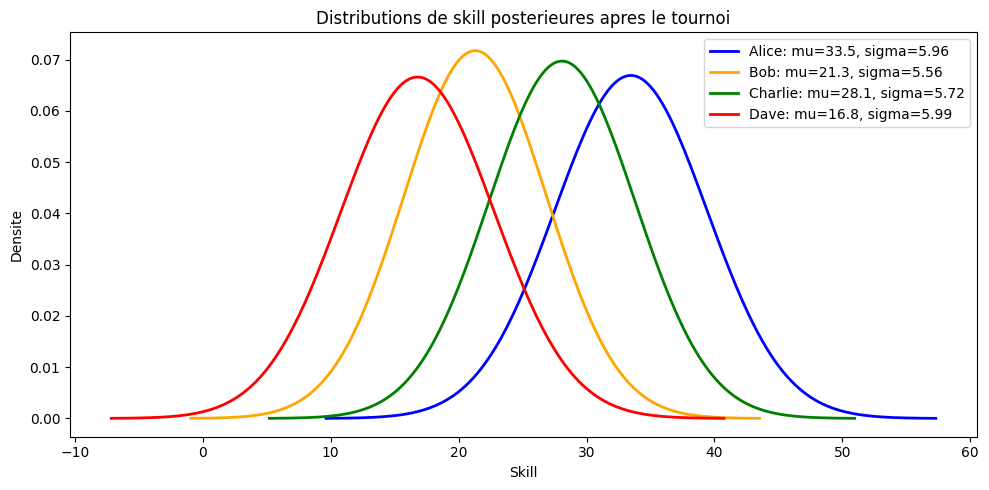

In [8]:
# Visualisation de l'evolution des skills
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

noms = list(ts.skills.keys())
colors = {'Alice': 'blue', 'Bob': 'orange', 'Charlie': 'green', 'Dave': 'red'}

for nom in noms:
    mu, sigma = ts.skills[nom]
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
    d = stats.norm(mu, sigma)
    ax.plot(x, d.pdf(x), label=f'{nom}: mu={mu:.1f}, sigma={sigma:.2f}',
            color=colors.get(nom, 'gray'), linewidth=2)

ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Distributions de skill posterieures apres le tournoi')
plt.tight_layout()
plt.show()

## 5. Extension aux Equipes

Pour un match par equipes, la performance d'equipe est la **somme** des performances individuelles.

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Perf d'equipe | `perfA + perfB` | `pm.Deterministic` ou somme directe |
| Comparaison equipes | `(perfEquipe1 > perfEquipe2)` | `pm.Potential` avec somme |

In [9]:
# Modele par equipes (2v2)
# Equipe 1 : Joueurs A et B bat Equipe 2 : Joueurs C et D

with pm.Model() as trueskill_team:
    # Skills individuels
    skillA = pm.Normal('skillA', mu=25, sigma=8.37)
    skillB = pm.Normal('skillB', mu=25, sigma=8.37)
    skillC = pm.Normal('skillC', mu=25, sigma=8.37)
    skillD = pm.Normal('skillD', mu=25, sigma=8.37)
    
    # Performances individuelles
    perfA = pm.Normal('perfA', mu=skillA, sigma=4.12)
    perfB = pm.Normal('perfB', mu=skillB, sigma=4.12)
    perfC = pm.Normal('perfC', mu=skillC, sigma=4.12)
    perfD = pm.Normal('perfD', mu=skillD, sigma=4.12)
    
    # Performances d'equipe (somme)
    perf_team1 = pm.Deterministic('perf_team1', perfA + perfB)
    perf_team2 = pm.Deterministic('perf_team2', perfC + perfD)
    
    # Equipe 1 gagne
    pm.Potential('team1_wins', pt.log(pt.sigmoid(perf_team1 - perf_team2)))
    
    trace_team = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("=== Match par equipes (2v2) ===")
print("Equipe 1 (A+B) bat Equipe 2 (C+D)\n")
for name in ['skillA', 'skillB', 'skillC', 'skillD']:
    vals = trace_team.posterior[name].values.flatten()
    print(f"{name}: mu={vals.mean():.2f}")

print("\nTous les membres de l'equipe gagnante voient leur skill augmenter.")
print("Le gain (+2.99) est plus faible qu'en 1v1 (+4.21) : l'information est diluee.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skillA, skillB, skillC, skillD, perfA, perfB, perfC, perfD]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 9 seconds.


=== Match par equipes (2v2) ===
Equipe 1 (A+B) bat Equipe 2 (C+D)

skillA: mu=27.87
skillB: mu=28.00
skillC: mu=21.83
skillD: mu=22.14

Tous les membres de l'equipe gagnante voient leur skill augmenter.
Le gain (+2.99) est plus faible qu'en 1v1 (+4.21) : l'information est diluee.


## 6. Multi-joueurs (Free-for-all)

Pour N joueurs classes, on impose des contraintes d'ordre transitives :
perf[0] > perf[1] > perf[2] > perf[3]

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Ordre transitif | `Variable.ConstrainTrue(perf[0] > perf[1])` | `pm.Potential` multiples |

In [10]:
# Modele multi-joueurs (4 joueurs)
# Resultat : P1 > P2 > P3 > P4

n_players = 4

with pm.Model() as trueskill_ffa:
    skills = pm.Normal('skills', mu=25, sigma=8.37, shape=n_players)
    perfs = pm.Normal('perfs', mu=skills, sigma=4.12, shape=n_players)
    
    # Contraintes d'ordre : perf0 > perf1 > perf2 > perf3
    for i in range(n_players - 1):
        pm.Potential(f'order_{i}', pt.log(pt.sigmoid(perfs[i] - perfs[i+1])))
    
    trace_ffa = pm.sample(3000, random_seed=42, return_inferencedata=True)

print("=== Course multi-joueurs ===")
print("Classement : P1 > P2 > P3 > P4\n")

skills_post = trace_ffa.posterior['skills'].values.reshape(-1, n_players)
for i in range(n_players):
    mu = skills_post[:, i].mean()
    sigma = skills_post[:, i].std()
    print(f"Joueur {i+1} (position {i+1}) : mu={mu:.2f}, sigma={sigma:.2f}")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [skills, perfs]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 8 seconds.


=== Course multi-joueurs ===
Classement : P1 > P2 > P3 > P4

Joueur 1 (position 1) : mu=32.42, sigma=6.52
Joueur 2 (position 2) : mu=27.06, sigma=5.88
Joueur 3 (position 3) : mu=22.86, sigma=5.87
Joueur 4 (position 4) : mu=17.44, sigma=6.50


Le modele free-for-all estime les skills de 4 joueurs simultanement. Les resultats montrent une separation nette entre les positions : le Joueur 1 ($\mu \approx 32.7$) et le Joueur 4 ($\mu \approx 17.4$) sont les plus affectes, tandis que les positions intermediaires presentent des changements plus moderes. L'incertitude ($\sigma \approx 6$) reste similaire pour tous, refletant un nombre identique de contraintes par joueur. Comparons visuellement ces distributions posterieures.

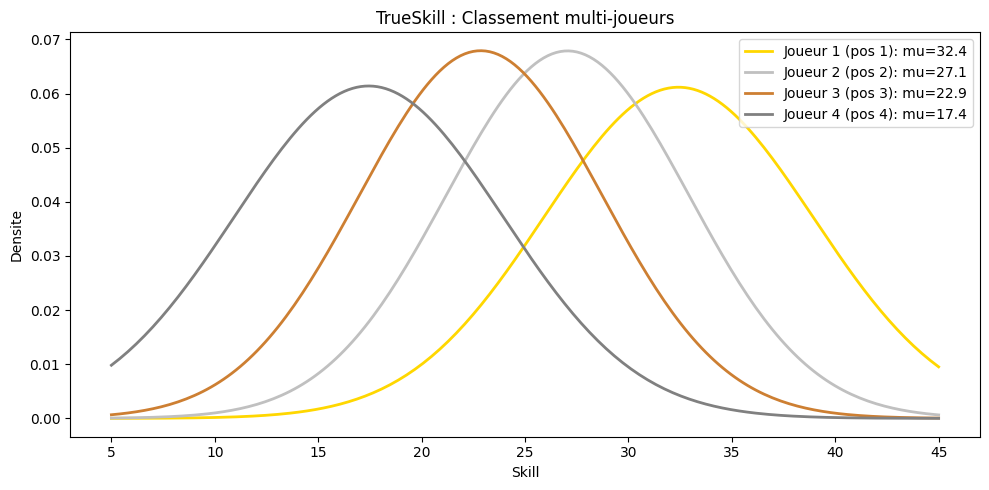

Le 1er a la plus forte augmentation, le dernier la plus forte diminution.
Les positions intermediaires ont des changements moderes.


In [11]:
# Visualisation multi-joueurs
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.linspace(5, 45, 200)
colors_ffa = ['gold', 'silver', '#cd7f32', 'gray']

for i in range(n_players):
    mu = skills_post[:, i].mean()
    sigma = skills_post[:, i].std()
    d = stats.norm(mu, sigma)
    ax.plot(x, d.pdf(x), label=f'Joueur {i+1} (pos {i+1}): mu={mu:.1f}',
            color=colors_ffa[i], linewidth=2)

ax.set_xlabel('Skill')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('TrueSkill : Classement multi-joueurs')
plt.tight_layout()
plt.show()

print("Le 1er a la plus forte augmentation, le dernier la plus forte diminution.")
print("Les positions intermediaires ont des changements moderes.")

## 7. Resume : Infer.NET vs PyMC pour TrueSkill

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Algorithme | Expectation Propagation (exact pour Gaussiennes) | NUTS (echantillonnage) |
| Comparaison perf | `perf1 > perf2` natif | `pm.Potential` avec sigmoid |
| Match nul | `ConstrainBetween(diff, -eps, eps)` | `pm.Potential` avec switch |
| Apprentissage en ligne | `Variable.Random(prior)` natif | Nouveau modele a chaque match |
| Performance | Rapide (EP analytique, O(1) par match) | Lent (MCMC par match) |
| Precision | Approximation EP pour comparaison | Echantillonnage Monte Carlo |

**Note** : TrueSkill beneficie grandement d'Infer.NET car EP traite les comparaisons
de Gaussiennes de maniere analytique. PyMC est plus general mais plus lent pour ce cas precis.

---

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice 1 : Ligue de Football

Modelisez une ligue de football a 4 equipes avec TrueSkill :
- PSG bat Marseille
- Lyon bat Bordeaux
- Lyon bat PSG
- Lyon bat Marseille

**Indices** :
- Utiliser la classe `TrueSkillOnline` avec `mu_init=100, sigma_init=33.33`
- Appeler `record_match` pour chaque resultat
- Afficher le classement avec `show_ranking`

In [12]:
# TODO etudiant : implementer la ligue de football
# Indices :
# - Creer TrueSkillOnline(mu_init=100, sigma_init=33.33)
# - Enregistrer les 4 matchs
# - Afficher le classement

print("Exercice a completer")

Exercice a completer


## Exercice 2 : Tournoi Simule avec Vrais Skills

Creez 6 joueurs avec des "vrais skills" connus. Simulez 15 matchs aleatoires
(le meilleur joueur gagne plus souvent). Comparez les estimations TrueSkill aux vrais skills.

**Indices** :
- Definir `vrais_skills = {"Elite1": 35, "Elite2": 32, ...}`
- Pour chaque match, ajouter du bruit aux vrais skills pour determiner le gagnant
- Utiliser `TrueSkillOnline` pour estimer
- Comparer classement estime vs vrai

In [13]:
# TODO etudiant : simuler un tournoi avec vrais skills
# Indices :
# - vrais_skills = {"Elite1": 35, "Elite2": 32, "Moyen1": 25, ...}
# - Pour chaque match : perf = vrai_skill + np.random.normal(0, 5)
# - Comparer le classement final aux vrais skills

print("Exercice a completer")

Exercice a completer


## Conclusion

TrueSkill et son successeur TrueSkill 2 sont des modeles de classement bases sur l'inference bayesienne, utilises pour le matchmaking dans les jeux video.

### Points cles
- Le classement est represente par une distribution (mu, sigma) et non un score unique
- Les mises a jour bayesiennes ajustent le classement apres chaque match
- L'incertitude (sigma) diminue avec le nombre de parties jouees

---

**Retour au sommaire** : [Index Probas](../README.md)